# Traveling Salesman Problem (TSP) – CPLEX / DOcplex Version

This notebook contains **only the TSP-related content**, converted to **IBM CPLEX using DOcplex**,
and is fully compatible with **Google Colab**.

The mathematical formulation and logic remain the same as the original tutorial.

In [1]:
!pip install cplex docplex

In [2]:
from docplex.mp.model import Model
import numpy as np


## TSP Data

In [3]:
n = 6  # number of cities
cities = range(n)

# Distance matrix
dist = np.array([
    [0, 10, 15, 20, 10, 25],
    [10, 0, 35, 25, 17, 30],
    [15, 35, 0, 30, 28, 40],
    [20, 25, 30, 0, 22, 18],
    [10, 17, 28, 22, 0, 14],
    [25, 30, 40, 18, 14, 0]
])


## TSP Model (MTZ Formulation)

In [4]:
mdl = Model('TSP')

# Decision variables
x = mdl.binary_var_dict(((i, j) for i in cities for j in cities if i != j), name='x')
u = mdl.continuous_var_dict(cities, lb=0, ub=n-1, name='u')

# Objective: minimize travel distance
mdl.minimize(mdl.sum(dist[i][j] * x[i, j] for i, j in x))

# Each city has exactly one outgoing arc
for i in cities:
    mdl.add_constraint(mdl.sum(x[i, j] for j in cities if i != j) == 1)

# Each city has exactly one incoming arc
for j in cities:
    mdl.add_constraint(mdl.sum(x[i, j] for i in cities if i != j) == 1)

# MTZ subtour elimination constraints
for i in cities:
    for j in cities:
        if i != j and i != 0 and j != 0:
            mdl.add_constraint(u[i] - u[j] + n * x[i, j] <= n - 1)


## Solve TSP using CPLEX

In [5]:
solution = mdl.solve(log_output=True)

if solution:
    print('Optimal tour length:', mdl.objective_value)
    tour = [(i, j) for (i, j) in x if x[i, j].solution_value > 0.5]
    print('Tour edges:', tour)
else:
    print('No solution found')


Version identifier: 22.1.2.0 | 2024-12-09 | 8bd2200c8
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
MIP Presolve eliminated 0 rows and 1 columns.
Reduced MIP has 32 rows, 35 columns, and 120 nonzeros.
Reduced MIP has 30 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.03 sec. (0.06 ticks)
Found incumbent of value 136.000000 after 0.05 sec. (0.17 ticks)
Probing time = 0.00 sec. (0.04 ticks)
Tried aggregator 1 time.
Detecting symmetries...
Reduced MIP has 32 rows, 35 columns, and 120 nonzeros.
Reduced MIP has 30 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.02 sec. (0.08 ticks)
Probing time = 0.00 sec. (0.04 ticks)
Clique table members: 22.
MIP emphasis: balance optimality and feasibility.
MIP search method: dynamic search.
Parallel mode: deterministic, using up to 12 threads.
Root relaxation solution time = 0.00 sec. (0.07 ticks)

        Nodes                                         Cuts/
   Node  Left     Objective  II

## Reconstruct Tour

In [ ]:
current = 0
tour_path = [current]

while len(tour_path) < n:
    for (i, j) in tour:
        if i == current:
            tour_path.append(j)
            current = j
            break

tour_path.append(tour_path[0])
print('Tour order:', tour_path)


Tour order: [0, 1, 4, 5, 3, 2, 0]


In [6]:
from docplex.mp.model import Model
import numpy as np

# -------------------------------
# Create random TSP problem data
# -------------------------------
n = 50
CITIES = range(n)

np.random.seed(0)

X = 100 * np.random.rand(n)
Y = 100 * np.random.rand(n)

# Compute distance matrix (same as Xpress code)
dist = np.ceil(
    np.sqrt(
        (X.reshape(n,1) - X.reshape(1,n))**2 +
        (Y.reshape(n,1) - Y.reshape(1,n))**2
    )
)

# -------------------------------
# Create CPLEX model
# -------------------------------
mdl = Model("TSP")

# Binary decision variables x[i,j]
x = mdl.binary_var_matrix(CITIES, CITIES, name="x")

# -------------------------------
# Degree constraints
# -------------------------------
# One outgoing arc per city
for i in CITIES:
    mdl.add_constraint(mdl.sum(x[i, j] for j in CITIES) == 1)

# One incoming arc per city
for j in CITIES:
    mdl.add_constraint(mdl.sum(x[i, j] for i in CITIES) == 1)

# -------------------------------
# Fix diagonals (no self-loops)
# -------------------------------
for i in CITIES:
    mdl.add_constraint(x[i, i] == 0)

# -------------------------------
# Objective function
# -------------------------------
mdl.minimize(
    mdl.sum(dist[i, j] * x[i, j] for i in CITIES for j in CITIES)
)

# -------------------------------
# Solve
# -------------------------------
solution = mdl.solve(log_output=True)

# -------------------------------
# Output solution
# -------------------------------
if solution:
    print("Optimal tour length:", mdl.objective_value)
    tour_edges = [(i, j) for i in CITIES for j in CITIES if x[i, j].solution_value > 0.5]
    print("Selected edges:")
    for e in tour_edges:
        print(e)
else:
    print("No solution found")

Using size restricted mode (Could not find directory for cpxchecklic).
CPLEX Error  1016: Community Edition. Problem size limits exceeded. Purchase at http://ibm.biz/error1016.


DOcplexLimitsExceeded: **** Promotional version. Problem size limits (1000 vars, 1000 consts) exceeded, model has 2500 vars, 150 consts, CPLEX code=1016

In [10]:
import sys
sys.version

'3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]'

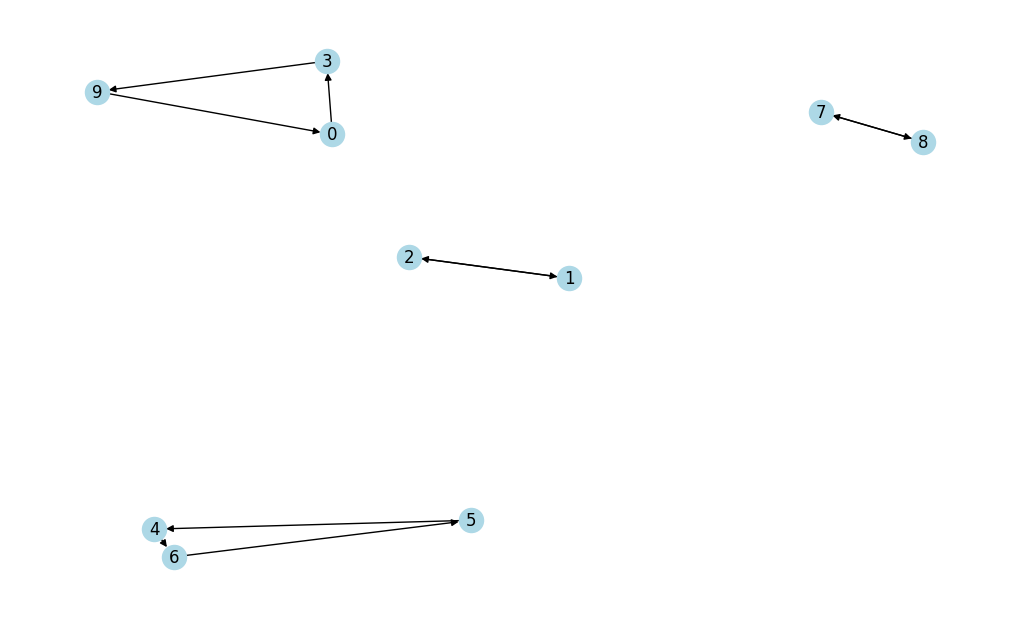

In [ ]:
# Visualize solution using networkx and matplotlib
import networkx as nx
import matplotlib.pyplot as plt
import itertools

def plot_sol(mdl, x):

    # collect the edges: if x[i,j] == 1, then (i,j) is in the solution
    edges = []
    for (i, j) in itertools.permutations(CITIES, 2):
        if x[i, j].solution_value > 0.5:   # binary variable
            edges.append((i, j))

    # coordinates for each node
    xy = {i: (X[i], Y[i]) for i in CITIES}

    # make figure look nicer
    plt.figure(figsize=(10, 6), dpi=100)

    # create graph
    optgraph = nx.DiGraph()   # directed graph (important for TSP)

    # add edges
    optgraph.add_edges_from(edges)

    # draw graph
    nx.draw(
        optgraph,
        pos=xy,
        with_labels=True,
        node_size=300,
        node_color='lightblue',
        arrows=True
    )

    plt.show()
if solution is None:
    print("No feasible solution found")
else:
    plot_sol(mdl, x)


In [ ]:
import itertools

# -----------------------------------------
# Add subtour elimination constraints (DFJ)
# -----------------------------------------
for L in range(2, len(CITIES)):
    for subset in itertools.combinations(CITIES, L):
        mdl.add_constraint(
            mdl.sum(x[i, j] for i in subset for j in subset) <= len(subset) - 1
        )

# -----------------------------------------
# Solve again
# -----------------------------------------
solution = mdl.solve(log_output=True)


Using size restricted mode (Could not find directory for cpxchecklic).
CPLEX Error  1016: Community Edition. Problem size limits exceeded. Purchase at http://ibm.biz/error1016.


DOcplexLimitsExceeded: **** Promotional version. Problem size limits (1000 vars, 1000 consts) exceeded, model has 100 vars, 1042 consts, CPLEX code=1016

In [ ]:
if solution is None:
    print("No feasible solution found")
else:
    plot_sol(mdl, x)


DOcplexException: Model<TSP> did not solve successfully

Version identifier: 22.1.2.0 | 2024-12-10 | f4cec290b
CPXPARAM_Read_DataCheck                          1
Tried aggregator 1 time.
MIP Presolve eliminated 19 rows and 11 columns.
Reduced MIP has 92 rows, 99 columns, and 396 nonzeros.
Reduced MIP has 90 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.00 sec. (0.21 ticks)
Found incumbent of value 571.000000 after 0.01 sec. (0.40 ticks)
Probing time = 0.00 sec. (0.20 ticks)
Tried aggregator 1 time.
Detecting symmetries...
Reduced MIP has 92 rows, 99 columns, and 396 nonzeros.
Reduced MIP has 90 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.00 sec. (0.27 ticks)
Probing time = 0.00 sec. (0.21 ticks)
Clique table members: 56.
MIP emphasis: balance optimality and feasibility.
MIP search method: dynamic search.
Parallel mode: deterministic, using up to 2 threads.
Root relaxation solution time = 0.00 sec. (0.17 ticks)

        Nodes                                         Cuts/
   Node  Left     Objective  I

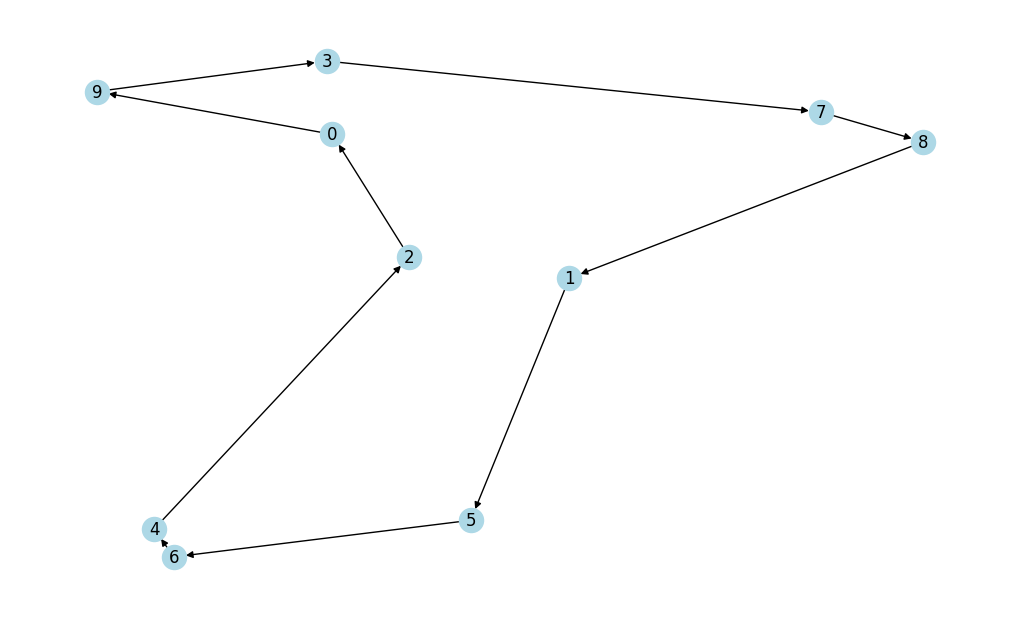

In [ ]:
from docplex.mp.model import Model

# -------------------------------
# Create model
# -------------------------------
mdl = Model("TSP_MTZ")

# -------------------------------
# Decision variables
# -------------------------------
# Binary arc variables
x = mdl.binary_var_matrix(CITIES, CITIES, name="x")

# MTZ ordering variables
t = mdl.continuous_var_list(n, lb=0, ub=n-1, name="t")

# -------------------------------
# Degree constraints
# -------------------------------
# One outgoing arc per city
for i in CITIES:
    mdl.add_constraint(mdl.sum(x[i, j] for j in CITIES) == 1)

# One incoming arc per city
for j in CITIES:
    mdl.add_constraint(mdl.sum(x[i, j] for i in CITIES) == 1)

# -------------------------------
# Fix diagonals (no self-loops)
# -------------------------------
for i in CITIES:
    mdl.add_constraint(x[i, i] == 0)

# -------------------------------
# MTZ subtour elimination constraints
# (same logic as your Xpress code)
# -------------------------------
for i in range(1, n):
    for j in range(1, n):
        mdl.add_constraint(
            t[j] >= t[i] + 1 - (n - 1) * (1 - x[i, j])
        )

# -------------------------------
# Objective function
# -------------------------------
mdl.minimize(
    mdl.sum(dist[i, j] * x[i, j] for i in CITIES for j in CITIES)
)

# -------------------------------
# Solve
# -------------------------------
solution = mdl.solve(log_output=True)

# -------------------------------
# Plot solution
# -------------------------------
if solution is None:
    print("No feasible solution found")
else:
    plot_sol(mdl, x)


Version identifier: 22.1.2.0 | 2024-12-10 | f4cec290b
CPXPARAM_Read_DataCheck                          1
Tried aggregator 2 times.
MIP Presolve eliminated 38 rows and 30 columns.
MIP Presolve modified 189 coefficients.
Aggregator did 9 substitutions.
Reduced MIP has 389 rows, 171 columns, and 1062 nonzeros.
Reduced MIP has 90 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.01 sec. (1.17 ticks)
Found incumbent of value 395.000000 after 0.01 sec. (1.43 ticks)
Probing time = 0.00 sec. (0.63 ticks)
Cover probing fixed 0 vars, tightened 9 bounds.
Tried aggregator 1 time.
Detecting symmetries...
MIP Presolve eliminated 9 rows and 0 columns.
MIP Presolve modified 144 coefficients.
Reduced MIP has 380 rows, 171 columns, and 1044 nonzeros.
Reduced MIP has 90 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.01 sec. (0.95 ticks)
Probing time = 0.00 sec. (0.63 ticks)
Clique table members: 20.
MIP emphasis: balance optimality and feasibility.
MIP search method: dy

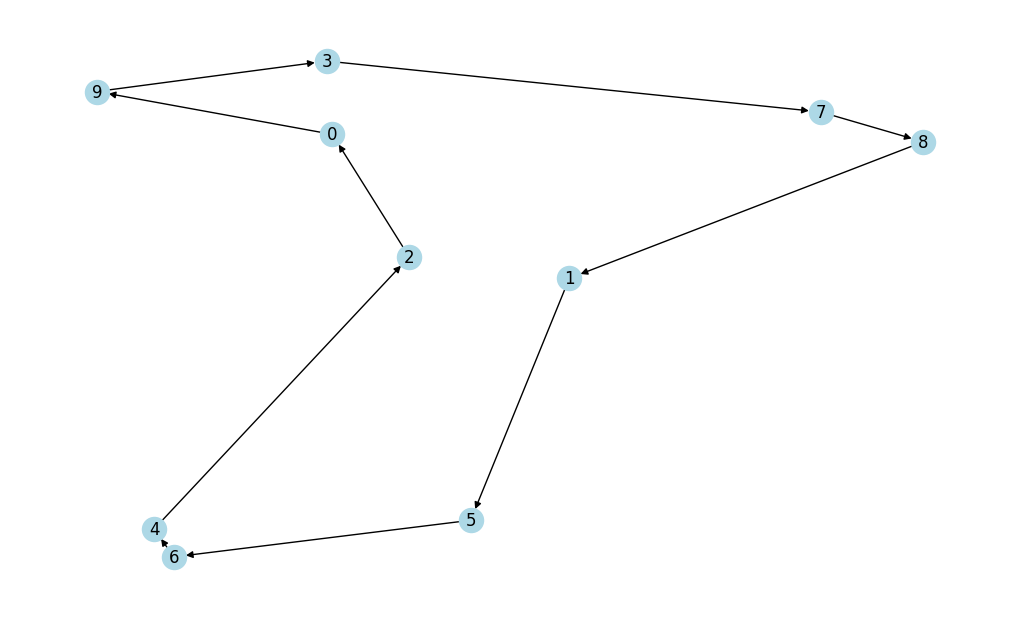

In [ ]:
from docplex.mp.model import Model

# -------------------------------
# Create model
# -------------------------------
mdl = Model("TSP_MTZ")

# -------------------------------
# Decision variables
# -------------------------------
# Binary arc variables
x = mdl.binary_var_matrix(CITIES, CITIES, name="x")

z= mdl.continuous_var_matrix(CITIES, CITIES, lb=0, ub=n, name="z")

# MTZ ordering variables
u = mdl.continuous_var_list(n, lb=1, ub=n, name="u")

# -------------------------------
# Degree constraints
# -------------------------------
# One outgoing arc per city
for i in CITIES:
    mdl.add_constraint(mdl.sum(x[i, j] for j in CITIES) == 1)

# One incoming arc per city
for j in CITIES:
    mdl.add_constraint(mdl.sum(x[i, j] for i in CITIES) == 1)

# -------------------------------
# Fix diagonals (no self-loops)
# -------------------------------
for i in CITIES:
    mdl.add_constraint(x[i, i] == 0)

# -------------------------------
# MTZ subtour elimination constraints
# (same logic as your Xpress code)
# -------------------------------
for i in range(0, n):
    for j in range(1, n):
      if i!=j:
        mdl.add_constraint(u[j] >= z[i,j] + x[i,j])
        mdl.add_constraint(z[i,j] >= x[i,j])
        mdl.add_constraint(z[i,j] <= n*x[i,j])
        mdl.add_constraint(z[i,j] <= u[i]-1*(1-x[i,j]))
        mdl.add_constraint(z[i,j] >= u[i]-n*(1-x[i,j]))


mdl.add_constraint(u[0] == 1)
# -------------------------------
# Objective function
# -------------------------------
mdl.minimize(
    mdl.sum(dist[i, j] * x[i, j] for i in CITIES for j in CITIES)
)

# -------------------------------
# Solve
# -------------------------------
solution = mdl.solve(log_output=True)

# -------------------------------
# Plot solution
# -------------------------------
if solution is None:
    print("No feasible solution found")
else:
    plot_sol(mdl, x)

In [ ]:
n

10

In [ ]:
!pip install docplex.mp.callbacks

ERROR: Could not find a version that satisfies the requirement docplex.mp.callbacks (from versions: none)
ERROR: No matching distribution found for docplex.mp.callbacks


In [ ]:
# ================= SINGLE CELL: TSP with Lazy Subtour Elimination (CPLEX) =================

!pip install cplex docplex networkx matplotlib

from docplex.mp.model import Model
from docplex.mp.callbacks import LazyConstraintCallback
import numpy as np
import itertools
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------------
# Data generation (same as Xpress)
# -------------------------------
n = 7
CITIES = range(n)

np.random.seed(0)
X = 100 * np.random.rand(n)
Y = 100 * np.random.rand(n)

dist = np.ceil(
    np.sqrt(
        (X.reshape(n,1) - X.reshape(1,n))**2 +
        (Y.reshape(n,1) - Y.reshape(1,n))**2
    )
)

# -------------------------------
# Model (NO subtour constraints)
# -------------------------------
mdl = Model("TSP_Lazy")

x = mdl.binary_var_matrix(CITIES, CITIES, name="x")

# Degree constraints
for i in CITIES:
    mdl.add_constraint(mdl.sum(x[i, j] for j in CITIES) == 1)
for j in CITIES:
    mdl.add_constraint(mdl.sum(x[i, j] for i in CITIES) == 1)

# No self-loops
for i in CITIES:
    mdl.add_constraint(x[i, i] == 0)

# Objective
mdl.minimize(mdl.sum(dist[i, j] * x[i, j] for i in CITIES for j in CITIES))

# -------------------------------
# Subtour detection
# -------------------------------
def find_subtours(successor, n):
    visited = [False]*n
    tours = []
    for start in range(n):
        if not visited[start]:
            tour = [start]
            visited[start] = True
            nxt = start
            while True:
                nxt = successor[nxt]
                if visited[nxt]:
                    break
                tour.append(nxt)
                visited[nxt] = True
            tours.append(tour)
    return tours

# -------------------------------
# Lazy constraint callback
# -------------------------------
class TSPLazyCallback(LazyConstraintCallback):
    def __call__(self):
        successor = {}
        for i in CITIES:
            for j in CITIES:
                if i != j and self.get_value(x[i, j]) > 0.5:
                    successor[i] = j
                    break

        tours = find_subtours(successor, n)

        if len(tours) > 1:
            for tour in tours:
                if len(tour) < n:
                    self.add(
                        self.sum(x[i, j]
                                 for i in tour
                                 for j in tour
                                 if i != j) <= len(tour) - 1
                    )

mdl.register_callback(TSPLazyCallback)

# -------------------------------
# Solve
# -------------------------------
solution = mdl.solve(log_output=True)

# -------------------------------
# Plot solution
# -------------------------------
def plot_sol():
    edges = [(i, j) for i in CITIES for j in CITIES if x[i, j].solution_value > 0.5]
    pos = {i: (X[i], Y[i]) for i in CITIES}

    G = nx.DiGraph()
    G.add_edges_from(edges)

    plt.figure(figsize=(10,6), dpi=100)
    nx.draw(G, pos, with_labels=True, node_color="lightblue",
            node_size=300, arrows=True)
    plt.show()

if solution:
    print("Optimal tour length:", mdl.objective_value)
    plot_sol()
else:
    print("No feasible solution found")


ImportError: cannot import name 'LazyConstraintCallback' from 'docplex.mp.callbacks' (/usr/local/lib/python3.12/dist-packages/docplex/mp/callbacks/__init__.py)

In [ ]:
# ================= SINGLE CELL: TSP with Lazy Subtour Elimination (CPLEX) =================

!pip install cplex docplex networkx matplotlib

from docplex.mp.model import Model
from docplex.mp.callbacks.cb_mixin import LazyConstraintCallback
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------------
# Data generation
# -------------------------------
n = 17
CITIES = range(n)

np.random.seed(0)
X = 100 * np.random.rand(n)
Y = 100 * np.random.rand(n)

dist = np.ceil(
    np.sqrt(
        (X.reshape(n,1) - X.reshape(1,n))**2 +
        (Y.reshape(n,1) - Y.reshape(1,n))**2


SyntaxError: incomplete input (ipython-input-1138510575.py, line 24)

In [ ]:
# ================= SINGLE CELL: TSP with Lazy Subtour Elimination (CPLEX) =================

!pip install cplex docplex networkx matplotlib

from docplex.mp.model import Model
from docplex.mp.callbacks.cb_mixin import LazyConstraintCallback
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# -------------------------------
# Data generation
# -------------------------------
n = 17
CITIES = range(n)

np.random.seed(0)
X = 100 * np.random.rand(n)
Y = 100 * np.random.rand(n)

# ✅ FIXED: all parentheses are now balanced
dist = np.ceil(
    np.sqrt(
        (X.reshape(n, 1) - X.reshape(1, n))**2 +
        (Y.reshape(n, 1) - Y.reshape(1, n))**2
    )
)

# -------------------------------
# Model (NO subtour constraints)
# -------------------------------
mdl = Model("TSP_Lazy")

x = mdl.binary_var_matrix(CITIES, CITIES, name="x")

# Degree constraints
for i in CITIES:
    mdl.add_constraint(mdl.sum(x[i, j] for j in CITIES) == 1)
for j in CITIES:
    mdl.add_constraint(mdl.sum(x[i, j] for i in CITIES) == 1)

# No self-loops
for i in CITIES:
    mdl.add_constraint(x[i, i] == 0)

# Objective
mdl.minimize(
    mdl.sum(dist[i, j] * x[i, j] for i in CITIES for j in CITIES)
)

# -------------------------------
# Subtour detection
# -------------------------------
def find_subtours(successor):
    visited = [False] * n
    tours = []
    for start in range(n):
        if not visited[start]:
            tour = [start]
            visited[start] = True
            nxt = start
            while True:
                nxt = successor[nxt]
                if visited[nxt]:
                    break
                tour.append(nxt)
                visited[nxt] = True
            tours.append(tour)
    return tours

# -------------------------------
# Lazy constraint callback
# -------------------------------
class TSPLazyCallback(LazyConstraintCallback):
    def __call__(self):
        successor = {}
        for i in CITIES:
            for j in CITIES:
                if i != j and self.get_value(x[i, j]) > 0.5:
                    successor[i] = j
                    break

        tours = find_subtours(successor)

        if len(tours) > 1:
            for tour in tours:
                if len(tour) < n:
                    self.add(
                        self.sum(x[i, j]
                                 for i in tour
                                 for j in tour
                                 if i != j) <= len(tour) - 1
                    )

mdl.register_callback(TSPLazyCallback)

# -------------------------------
# Solve
# -------------------------------
solution = mdl.solve(log_output=True)

# -------------------------------
# Plot solution
# -------------------------------
def plot_sol():
    edges = [(i, j) for i in CITIES for j in CITIES if x[i, j].solution_value > 0.5]
    pos = {i: (X[i], Y[i]) for i in CITIES}

    G = nx.DiGraph()
    G.add_edges_from(edges)

    plt.figure(figsize=(10, 6), dpi=100)
    nx.draw(G, pos, with_labels=True, node_color="lightblue",
            node_size=300, arrows=True)
    plt.show()

if solution:
    print("Optimal tour length:", mdl.objective_value)
    plot_sol()
else:
    print("No feasible solution found")


ImportError: cannot import name 'LazyConstraintCallback' from 'docplex.mp.callbacks.cb_mixin' (/usr/local/lib/python3.12/dist-packages/docplex/mp/callbacks/cb_mixin.py)